In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [2]:
final_dataset = pd.read_csv('mosquito_park_final_data.csv', index_col='tm', parse_dates=True)
final_dataset.head()

,TEMP_AVG,HUMID,WT_AVG,DO,RN_SUM_7,TG_MIN,MOS_PARK
tm,,,,,,,
2020-05-07,20.7,32.5,21.770541,6.286111,0.0,11.6,21.6
2020-05-08,19.9,32.8,21.755556,6.190278,2.3,11.7,59.4
2020-05-09,14.2,94.4,19.347222,4.212500,26.7,11.9,63.6
2020-05-10,14.4,88.6,18.548611,4.976389,28.0,12.2,61.0
2020-05-11,16.5,61.0,19.930177,5.525253,31.4,9.8,45.3


In [3]:
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1087 entries, 2020-05-07 to 2025-10-31
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TEMP_AVG  1087 non-null   float64
 1   HUMID     1087 non-null   float64
 2   WT_AVG    1087 non-null   float64
 3   DO        1087 non-null   float64
 4   RN_SUM_7  1087 non-null   float64
 5   TG_MIN    1087 non-null   float64
 6   MOS_PARK  1087 non-null   float64
dtypes: float64(7)
memory usage: 67.9 KB


In [4]:
final_df = final_dataset.copy()
features = final_dataset.columns
features

Index(['TEMP_AVG', 'HUMID', 'WT_AVG', 'DO', 'RN_SUM_7', 'TG_MIN', 'MOS_PARK'], dtype='object')

In [5]:
print("현재 설정된 타겟(y) 컬럼:", final_df.columns[-1])

현재 설정된 타겟(y) 컬럼: MOS_PARK


In [6]:
def s_train_val_test(df, target_col):
    # 9:1:1 분할 (이전 코드 활용)
    n = len(df)
    train_end = int(n * 0.82)
    val_end = int(n * 0.91)
    
    train = df.iloc[:train_end]
    val = df.iloc[train_end:val_end]
    test = df.iloc[val_end:]
    
    return train, val, test

def s_train_val_test(df):
    # 9:1:1 분할 (이전 코드 활용)
    n = len(df)
    train_end = int(n * 0.82)
    val_end = int(n * 0.91)
    
    train = df.iloc[:train_end]
    val = df.iloc[train_end:val_end]
    test = df.iloc[val_end:]
    
    # 해당 타겟 전용 스케일러 생성 및 적용
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train)
    scaled_val = scaler.transform(val)
    scaled_test = scaler.transform(test)
    
    return scaled_train, scaled_val, scaled_test, scaler


s_park_train, s_park_val, s_park_test, park_scaler = s_train_val_test(final_df)
print(f"Train: {len(s_park_train)}, Val: {len(s_park_val)}, Test: {len(s_park_test)}")

Train: 891, Val: 98, Test: 98


In [7]:
def create_sequences(data, window_size=14):
    X, y = [], []
    for i in range(len(data) - window_size):
        # i부터 i+window_size 전까지는 입력 피처 (X)
        X.append(data[i:i+window_size, :-1]) 
        # i+window_size 시점의 마지막 컬럼은 정답 (y)
        y.append(data[i+window_size, -1])
    return np.array(X), np.array(y)

# Park 데이터셋 적용 (House도 동일하게 반복 가능)
window_size = 7
X_park_train, y_park_train = create_sequences(s_park_train, window_size)
X_park_val, y_park_val = create_sequences(s_park_val, window_size)
X_park_test, y_park_test = create_sequences(s_park_test, window_size)

print(f"학습 데이터 형태: {X_park_train.shape}") # (샘플 수, 14, 피처 수)

학습 데이터 형태: (884, 7, 6)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

# 모델 구조 정의
park_model_rnn = Sequential([
    # 1층 RNN: 시퀀스 데이터를 받아 처리
    SimpleRNN(64, return_sequences=True, input_shape=(X_park_train.shape[1], X_park_train.shape[2])),
    Dropout(0.2),
    # 2층 RNN: 좀 더 복잡한 패턴 학습
    SimpleRNN(32),
    Dropout(0.2),
    # 출력층: 최종 수치 예측
    Dense(16, activation='relu'),
    Dense(1)
])

park_model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 학습 시작
park_history = park_model_rnn.fit(
    X_park_train, y_park_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_park_val, y_park_val),
    verbose=1
)

Epoch 1/50
28/28 [==============================] - 1s 10ms/step - loss: 0.1198 - mae: 0.2480 - val_loss: 0.0251 - val_mae: 0.1315
Epoch 2/50
28/28 [==============================] - 0s 2ms/step - loss: 0.0364 - mae: 0.1517 - val_loss: 0.0141 - val_mae: 0.0918
Epoch 3/50
28/28 [==============================] - 0s 2ms/step - loss: 0.0299 - mae: 0.1377 - val_loss: 0.0140 - val_mae: 0.0916
Epoch 4/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0244 - mae: 0.1228 - val_loss: 0.0147 - val_mae: 0.0952
Epoch 5/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0212 - mae: 0.1145 - val_loss: 0.0158 - val_mae: 0.0964
Epoch 6/50
28/28 [==============================] - 0s 2ms/step - loss: 0.0200 - mae: 0.1117 - val_loss: 0.0200 - val_mae: 0.1094
Epoch 7/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0171 - mae: 0.1013 - val_loss: 0.0212 - val_mae: 0.1129
Epoch 8/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0161 - mae: 0.0

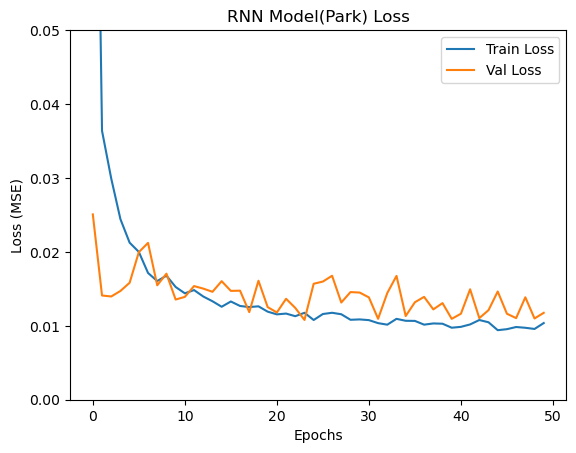

In [9]:
import matplotlib.pyplot as plt

plt.plot(park_history.history['loss'], label='Train Loss')
plt.plot(park_history.history['val_loss'], label='Val Loss')
plt.ylim(0, 0.05)
plt.title('RNN Model(Park) Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

LSTM(Park)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

def build_lstm_model(input_shape):
    model = Sequential([
        # 장기 기억을 위한 LSTM 레이어
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # 학습률을 약간 낮춰(0.0005) 진동을 방지합니다.
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# 1. Park용 LSTM 학습
model_lstm_park = build_lstm_model((X_park_train.shape[1], X_park_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=50, batch_size=32,
                                validation_data=(X_park_val, y_park_val))

Epoch 1/50
28/28 [==============================] - 3s 22ms/step - loss: 0.0575 - mae: 0.1901 - val_loss: 0.0320 - val_mae: 0.1534
Epoch 2/50
28/28 [==============================] - 0s 4ms/step - loss: 0.0197 - mae: 0.1100 - val_loss: 0.0354 - val_mae: 0.1600
Epoch 3/50
28/28 [==============================] - 0s 4ms/step - loss: 0.0174 - mae: 0.1013 - val_loss: 0.0242 - val_mae: 0.1231
Epoch 4/50
28/28 [==============================] - 0s 4ms/step - loss: 0.0141 - mae: 0.0924 - val_loss: 0.0193 - val_mae: 0.1044
Epoch 5/50
28/28 [==============================] - 0s 4ms/step - loss: 0.0151 - mae: 0.0940 - val_loss: 0.0204 - val_mae: 0.1089
Epoch 6/50
28/28 [==============================] - 0s 4ms/step - loss: 0.0140 - mae: 0.0929 - val_loss: 0.0166 - val_mae: 0.0971
Epoch 7/50
28/28 [==============================] - 0s 4ms/step - loss: 0.0136 - mae: 0.0905 - val_loss: 0.0149 - val_mae: 0.0913
Epoch 8/50
28/28 [==============================] - 0s 4ms/step - loss: 0.0128 - mae: 0.0

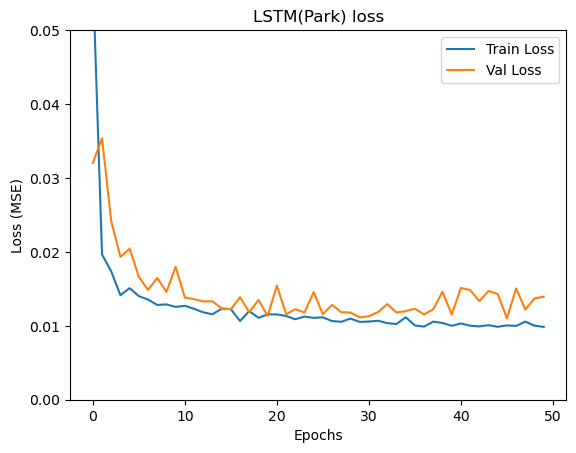

In [11]:
import matplotlib.pyplot as plt
def plot_history_fixed(history, title):
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.ylim(0, 0.05)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.show()

plot_history_fixed(history_p, 'LSTM(Park) loss')


학습률 조정

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

def build_lstm_model(input_shape):
    model = Sequential([
        # 장기 기억을 위한 LSTM 레이어
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # 학습률을 약간 낮춰(0.0005) 진동을 방지합니다.
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# 1. Park용 LSTM 학습
model_lstm_park = build_lstm_model((X_park_train.shape[1], X_park_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=50, batch_size=32,
                                validation_data=(X_park_val, y_park_val))

Epoch 1/50
28/28 [==============================] - 3s 21ms/step - loss: 0.1619 - mae: 0.3622 - val_loss: 0.0309 - val_mae: 0.1387
Epoch 2/50
28/28 [==============================] - 0s 4ms/step - loss: 0.0688 - mae: 0.2171 - val_loss: 0.0156 - val_mae: 0.0998
Epoch 3/50
28/28 [==============================] - 0s 4ms/step - loss: 0.0286 - mae: 0.1318 - val_loss: 0.0361 - val_mae: 0.1613
Epoch 4/50
28/28 [==============================] - 0s 4ms/step - loss: 0.0229 - mae: 0.1210 - val_loss: 0.0374 - val_mae: 0.1650
Epoch 5/50
28/28 [==============================] - 0s 4ms/step - loss: 0.0220 - mae: 0.1190 - val_loss: 0.0315 - val_mae: 0.1481
Epoch 6/50
28/28 [==============================] - 0s 4ms/step - loss: 0.0222 - mae: 0.1178 - val_loss: 0.0310 - val_mae: 0.1467
Epoch 7/50
28/28 [==============================] - 0s 4ms/step - loss: 0.0198 - mae: 0.1118 - val_loss: 0.0295 - val_mae: 0.1421
Epoch 8/50
28/28 [==============================] - 0s 4ms/step - loss: 0.0191 - mae: 0.1

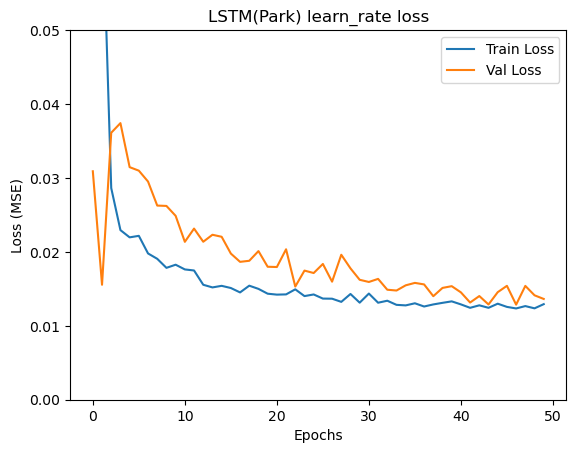

In [13]:
plot_history_fixed(history_p, 'LSTM(Park) learn_rate loss')

batch_size 조정

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

def build_lstm_model(input_shape):
    model = Sequential([
        # 장기 기억을 위한 LSTM 레이어
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # 학습률을 약간 낮춰(0.0005) 진동을 방지합니다.
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# 1. Park용 LSTM 학습
model_lstm_park = build_lstm_model((X_park_train.shape[1], X_park_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=50, batch_size=64,
                                validation_data=(X_park_val, y_park_val))

Epoch 1/50
14/14 [==============================] - 3s 42ms/step - loss: 0.1820 - mae: 0.3804 - val_loss: 0.0123 - val_mae: 0.0869
Epoch 2/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0358 - mae: 0.1495 - val_loss: 0.0780 - val_mae: 0.2603
Epoch 3/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0268 - mae: 0.1342 - val_loss: 0.0260 - val_mae: 0.1359
Epoch 4/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0237 - mae: 0.1200 - val_loss: 0.0314 - val_mae: 0.1518
Epoch 5/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0212 - mae: 0.1158 - val_loss: 0.0329 - val_mae: 0.1550
Epoch 6/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0195 - mae: 0.1124 - val_loss: 0.0256 - val_mae: 0.1311
Epoch 7/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0182 - mae: 0.1059 - val_loss: 0.0269 - val_mae: 0.1332
Epoch 8/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0164 - mae: 0.0

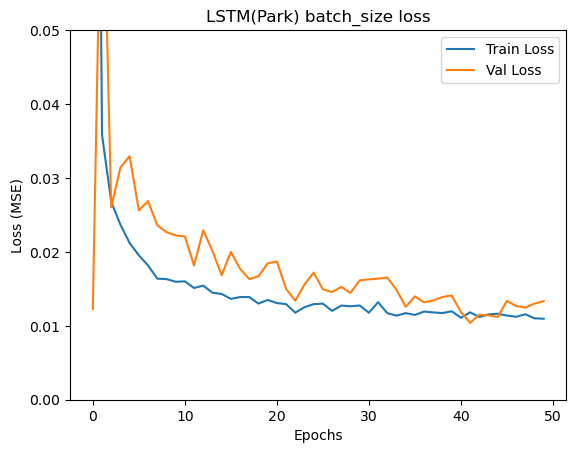

In [15]:
plot_history_fixed(history_p, 'LSTM(Park) batch_size loss')

Batch 64, learning_rate 0.0001

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

def build_lstm_model(input_shape):
    model = Sequential([
        # 장기 기억을 위한 LSTM 레이어
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # 학습률을 약간 낮춰(0.0005) 진동을 방지합니다.
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# 1. Park용 LSTM 학습
model_lstm_park = build_lstm_model((X_park_train.shape[1], X_park_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=50, batch_size=64,
                                validation_data=(X_park_val, y_park_val))

Epoch 1/50
14/14 [==============================] - 3s 38ms/step - loss: 0.2119 - mae: 0.4233 - val_loss: 0.0686 - val_mae: 0.2351
Epoch 2/50
14/14 [==============================] - 0s 5ms/step - loss: 0.1576 - mae: 0.3585 - val_loss: 0.0367 - val_mae: 0.1629
Epoch 3/50
14/14 [==============================] - 0s 5ms/step - loss: 0.1017 - mae: 0.2758 - val_loss: 0.0144 - val_mae: 0.0933
Epoch 4/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0574 - mae: 0.1937 - val_loss: 0.0116 - val_mae: 0.0836
Epoch 5/50
14/14 [==============================] - 0s 6ms/step - loss: 0.0330 - mae: 0.1426 - val_loss: 0.0249 - val_mae: 0.1310
Epoch 6/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0252 - mae: 0.1268 - val_loss: 0.0382 - val_mae: 0.1700
Epoch 7/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0243 - mae: 0.1268 - val_loss: 0.0382 - val_mae: 0.1696
Epoch 8/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0232 - mae: 0.1

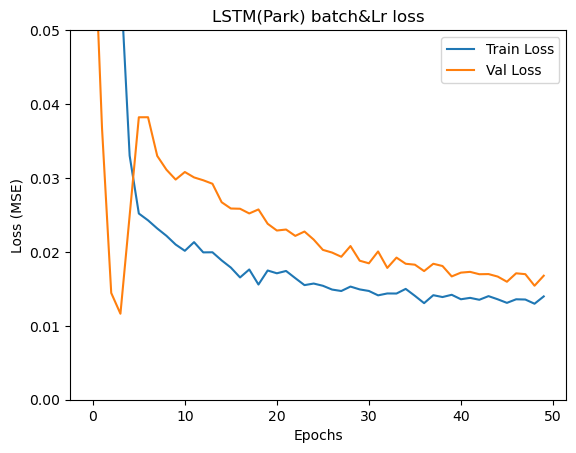

In [17]:
plot_history_fixed(history_p, 'LSTM(Park) batch&Lr loss')

Lr 0.001, BS 64

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

def build_lstm_model(input_shape):
    model = Sequential([
        # 장기 기억을 위한 LSTM 레이어
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # 학습률을 약간 낮춰(0.0005) 진동을 방지합니다.
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# 1. Park용 LSTM 학습
model_lstm_park = build_lstm_model((X_park_train.shape[1], X_park_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=50, batch_size=64,
                                validation_data=(X_park_val, y_park_val))

Epoch 1/50
14/14 [==============================] - 3s 40ms/step - loss: 0.0973 - mae: 0.2524 - val_loss: 0.0888 - val_mae: 0.2769
Epoch 2/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0268 - mae: 0.1311 - val_loss: 0.0164 - val_mae: 0.1005
Epoch 3/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0186 - mae: 0.1062 - val_loss: 0.0281 - val_mae: 0.1384
Epoch 4/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0164 - mae: 0.0990 - val_loss: 0.0221 - val_mae: 0.1159
Epoch 5/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0156 - mae: 0.0969 - val_loss: 0.0176 - val_mae: 0.0989
Epoch 6/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0148 - mae: 0.0941 - val_loss: 0.0174 - val_mae: 0.0992
Epoch 7/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0141 - mae: 0.0915 - val_loss: 0.0150 - val_mae: 0.0911
Epoch 8/50
14/14 [==============================] - 0s 5ms/step - loss: 0.0133 - mae: 0.0

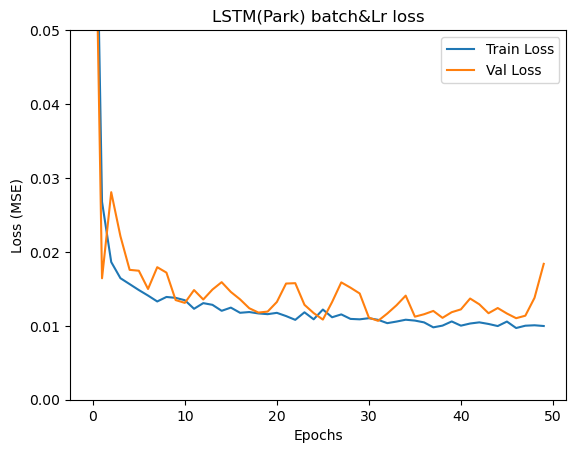

In [19]:
plot_history_fixed(history_p, 'LSTM(Park) batch&Lr loss')

ReduceLROnPlateau 적용

In [20]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# 설정: val_loss가 5회(patience) 동안 개선되지 않으면 
# 학습률을 0.2배(factor)로 줄임 (예: 0.001 -> 0.0002)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=5, 
    min_lr=0.00001, 
    verbose=1
)

def build_lstm_model(input_shape):
    model = Sequential([
        # 장기 기억을 위한 LSTM 레이어
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # 학습률을 약간 낮춰(0.0005) 진동을 방지합니다.
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# 1. Park용 LSTM 학습
model_lstm_park = build_lstm_model((X_park_train.shape[1], X_park_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=50, batch_size=64,
                                validation_data=(X_park_val, y_park_val), callbacks=[reduce_lr])

Epoch 1/50
14/14 [==============================] - 3s 42ms/step - loss: 0.0721 - mae: 0.2108 - val_loss: 0.0714 - val_mae: 0.2449 - lr: 0.0010
Epoch 2/50
14/14 [==============================] - 0s 9ms/step - loss: 0.0238 - mae: 0.1224 - val_loss: 0.0167 - val_mae: 0.1011 - lr: 0.0010
Epoch 3/50
14/14 [==============================] - 0s 8ms/step - loss: 0.0187 - mae: 0.1074 - val_loss: 0.0253 - val_mae: 0.1295 - lr: 0.0010
Epoch 4/50
14/14 [==============================] - 0s 8ms/step - loss: 0.0175 - mae: 0.1012 - val_loss: 0.0267 - val_mae: 0.1313 - lr: 0.0010
Epoch 5/50
14/14 [==============================] - 0s 9ms/step - loss: 0.0148 - mae: 0.0940 - val_loss: 0.0174 - val_mae: 0.0981 - lr: 0.0010
Epoch 6/50
14/14 [==============================] - 0s 9ms/step - loss: 0.0140 - mae: 0.0914 - val_loss: 0.0170 - val_mae: 0.0966 - lr: 0.0010
Epoch 7/50
14/14 [==============================] - 0s 8ms/step - loss: 0.0146 - mae: 0.0929 - val_loss: 0.0164 - val_mae: 0.0944 - lr: 0.001

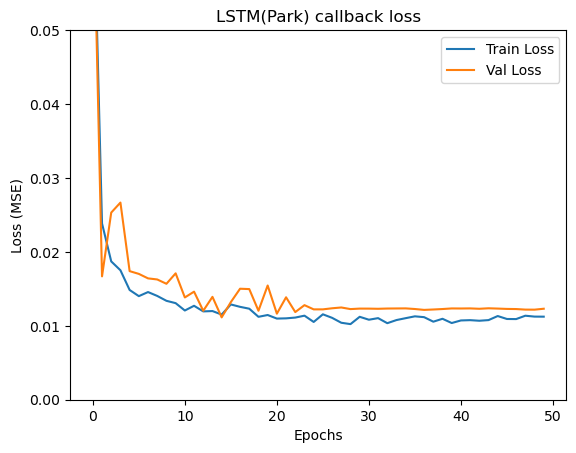

In [21]:
plot_history_fixed(history_p, 'LSTM(Park) callback loss')

에포크 수 조정

In [22]:
# 1. Park용 LSTM 학습
model_lstm_park = build_lstm_model((X_park_train.shape[1], X_park_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=30, batch_size=64,
                                validation_data=(X_park_val, y_park_val), callbacks=[reduce_lr])

Epoch 1/30
14/14 [==============================] - 3s 43ms/step - loss: 0.0780 - mae: 0.2264 - val_loss: 0.0546 - val_mae: 0.2100 - lr: 0.0010
Epoch 2/30
14/14 [==============================] - 0s 9ms/step - loss: 0.0240 - mae: 0.1202 - val_loss: 0.0193 - val_mae: 0.1102 - lr: 0.0010
Epoch 3/30
14/14 [==============================] - 0s 8ms/step - loss: 0.0178 - mae: 0.1059 - val_loss: 0.0201 - val_mae: 0.1106 - lr: 0.0010
Epoch 4/30
14/14 [==============================] - 0s 8ms/step - loss: 0.0164 - mae: 0.0987 - val_loss: 0.0232 - val_mae: 0.1180 - lr: 0.0010
Epoch 5/30
14/14 [==============================] - 0s 8ms/step - loss: 0.0147 - mae: 0.0938 - val_loss: 0.0175 - val_mae: 0.0968 - lr: 0.0010
Epoch 6/30
14/14 [==============================] - 0s 8ms/step - loss: 0.0143 - mae: 0.0915 - val_loss: 0.0175 - val_mae: 0.0980 - lr: 0.0010
Epoch 7/30
14/14 [==============================] - 0s 8ms/step - loss: 0.0136 - mae: 0.0888 - val_loss: 0.0145 - val_mae: 0.0885 - lr: 0.001

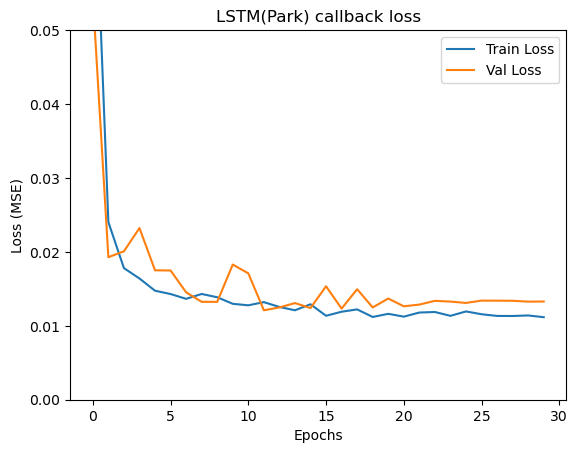

In [23]:
plot_history_fixed(history_p, 'LSTM(Park) callback loss')

예측

3/3 [==============================] - 0s 2ms/step


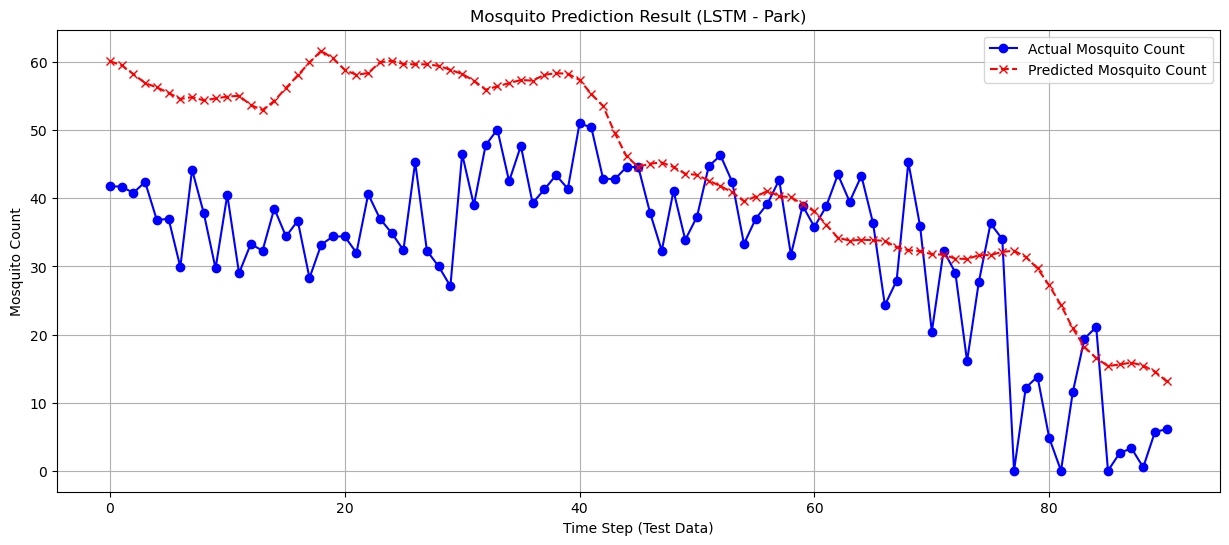

In [24]:
# 1. 테스트 데이터 예측
y_pred = model_lstm_park.predict(X_park_test)

# 2. 스케일링 역변환 (원래 마릿수로 복원)
# 예측값(y_pred)과 실제값(y_park_test) 모두 (85, 1) 형태로 확보합니다.
y_pred = y_pred.reshape(-1, 1)
y_actual = y_park_test.reshape(-1, 1)

# [수정 포인트] np.zeros의 열 개수는 'len(features)'여야 총 합이 (피처 + 타겟)이 됩니다.
# len(features)가 11개라면, 11개의 0 + 1개의 예측값 = 총 12개 컬럼 (스케일러 규격)

y_pred_rescaled = park_scaler.inverse_transform(
    np.concatenate([np.zeros((len(y_pred), len(list(features)[:-1]))), y_pred], axis=1)
)[:, -1]

y_actual_rescaled = park_scaler.inverse_transform(
    np.concatenate([np.zeros((len(y_actual), len(list(features)[:-1]))), y_actual], axis=1)
)[:, -1]

# 3. 결과 시각화
plt.figure(figsize=(15, 6))
plt.plot(y_actual_rescaled, label='Actual Mosquito Count', color='blue', marker='o')
plt.plot(y_pred_rescaled, label='Predicted Mosquito Count', color='red', linestyle='--', marker='x')
plt.title('Mosquito Prediction Result (LSTM - Park)')
plt.ylabel('Mosquito Count')
plt.xlabel('Time Step (Test Data)')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
from sklearn.metrics import mean_absolute_error, r2_score

# y_test와 y_pred는 본인의 변수명에 맞게 수정하세요.
mae = mean_absolute_error(y_actual_rescaled, y_pred_rescaled)
r2 = r2_score(y_actual_rescaled, y_pred_rescaled)

print(f"평균 절대 오차 (MAE): {mae:.2f}")
print(f"결정계수 (R2 Score): {r2:.2f}")

평균 절대 오차 (MAE): 13.14
결정계수 (R2 Score): -0.51


In [26]:
bias = (y_pred_rescaled - y_actual_rescaled).mean()
y_pred_corrected = y_pred_rescaled - bias

# 다시 계산해보면 R2가 플러스로 돌아설 확률이 매우 높습니다.
mae = mean_absolute_error(y_actual_rescaled, y_pred_corrected)
new_r2 = r2_score(y_actual_rescaled, y_pred_corrected)

print(f"편향 보정 후 평균 절대 오차 (MAE): {mae:.2f}")
print(f"편향 보정 후 R2 Score: {new_r2:.2f}")

편향 보정 후 평균 절대 오차 (MAE): 9.00
편향 보정 후 R2 Score: 0.31


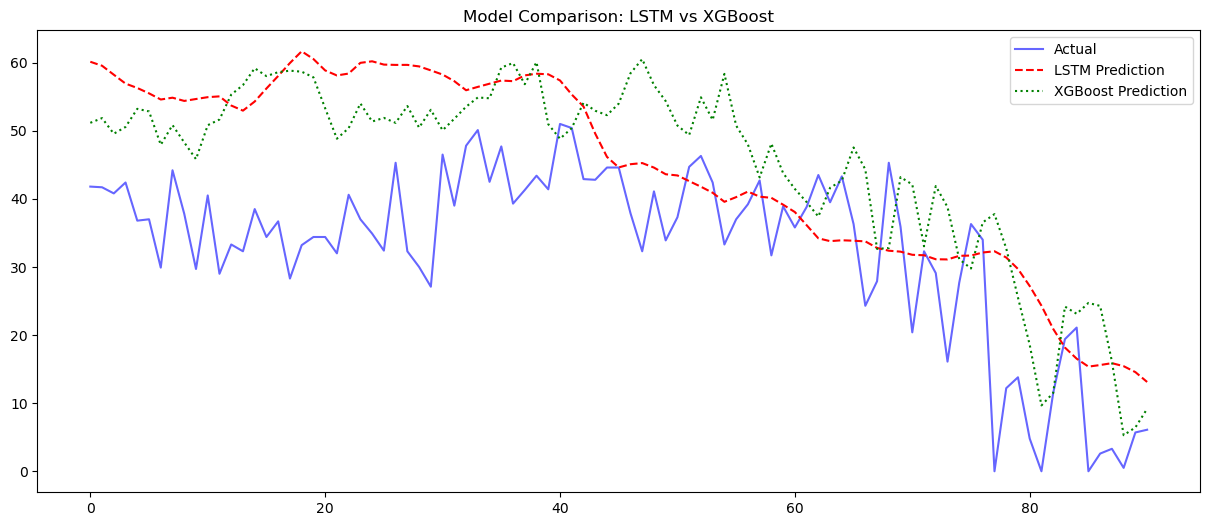

LSTM MSE: 249.4856
XGBoost MSE: 232.1789


In [27]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. 데이터 차원 변경 (3D -> 2D)
# (85, 14, 11) 형태를 (85, 14*11) 형태로 펼쳐줍니다.
X_train_flat = X_park_train.reshape(X_park_train.shape[0], -1)
X_val_flat = X_park_val.reshape(X_park_val.shape[0], -1)
X_test_flat = X_park_test.reshape(X_park_test.shape[0], -1)

# 2. XGBoost 모델 정의 및 학습
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(
    X_train_flat, y_park_train,
    eval_set=[(X_val_flat, y_park_val)],
    # early_stopping_rounds=50,
    verbose=False
)

# 3. 예측 및 역스케일링
y_pred_xgb = xgb_model.predict(X_test_flat).reshape(-1, 1)

y_pred_xgb_rescaled = park_scaler.inverse_transform(
    np.concatenate([np.zeros((len(y_pred_xgb), len(list(features)[:-1]))), y_pred_xgb], axis=1)
)[:, -1]

# 4. 결과 시각화 및 비교
plt.figure(figsize=(15, 6))
plt.plot(y_actual_rescaled, label='Actual', color='blue', alpha=0.6)
plt.plot(y_pred_rescaled, label='LSTM Prediction', color='red', linestyle='--')
plt.plot(y_pred_xgb_rescaled, label='XGBoost Prediction', color='green', linestyle=':')
plt.title('Model Comparison: LSTM vs XGBoost')
plt.legend()
plt.show()

# 5. 오차 수치 출력
print(f"LSTM MSE: {mean_squared_error(y_actual_rescaled, y_pred_rescaled):.4f}")
print(f"XGBoost MSE: {mean_squared_error(y_actual_rescaled, y_pred_xgb_rescaled):.4f}")

잔차 분석

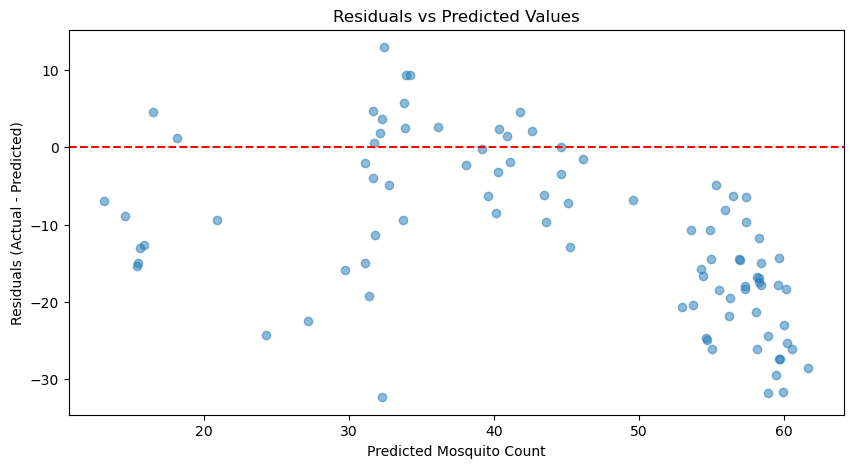

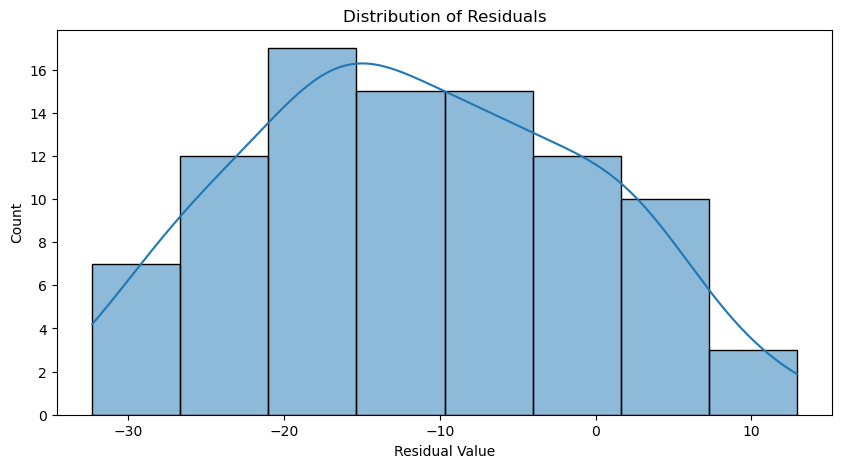

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 잔차 계산
residuals = y_actual_rescaled - y_pred_rescaled

# 2. 잔차 시각화 (Scatter Plot)
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_rescaled, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')  # 기준선 (오차 0)
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Mosquito Count')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

# 3. 잔차의 정규성 확인 (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residual Value')
plt.show()

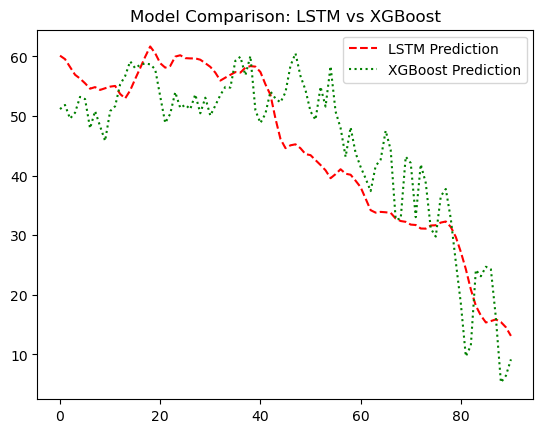

LSTM MSE: 249.4856
XGBoost MSE: 232.1789


In [28]:
plt.plot(y_pred_rescaled, label='LSTM Prediction', color='red', linestyle='--')
plt.plot(y_pred_xgb_rescaled, label='XGBoost Prediction', color='green', linestyle=':')
plt.title('Model Comparison: LSTM vs XGBoost')
plt.legend()
plt.show()

# 5. 오차 수치 출력
print(f"LSTM MSE: {mean_squared_error(y_actual_rescaled, y_pred_rescaled):.4f}")
print(f"XGBoost MSE: {mean_squared_error(y_actual_rescaled, y_pred_xgb_rescaled):.4f}")